# Data Lake - Jogos Olímpicos

## Fontes de Dados

Os dados utilizados neste projeto foram obtidos a partir das seguintes fontes públicas:
* [Base dos Dados – Histórico das Olimpíadas ](https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games)(`raw/athlete_event_result.csv`, `raw/athlete_bio.csv` e `raw/country.csv`)
* [Paris 2024 Olympic Summer Games Dataset ](https://basedosdados.org/dataset/62f8cb83-ac37-48be-874b-b94dd92d3e2b)(`raw/athletes.csv`, `raw/medals.csv` e `raw/nocs.csv`)

In [226]:
import pandas as pd
import json
from datetime import datetime
import matplotlib.pyplot as plt

## Leitura dos dados brutos

In [227]:
results = pd.read_csv("raw/athlete_event_result.csv")
bio = pd.read_csv("raw/athlete_bio.csv")
country = pd.read_csv("raw/country.csv")

athletes_2024 = pd.read_csv("raw/athletes.csv")
medals_2024 = pd.read_csv("raw/medals.csv")
nocs_2024 = pd.read_csv("raw/nocs.csv")

C:\Users\anafl\AppData\Local\Temp\ipykernel_5544\4171043409.py:1: DtypeWarning: Columns (0: medal) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("raw/athlete_event_result.csv")


In [228]:
for df in [results, bio, country, athletes_2024, medals_2024, nocs_2024]:
    df.columns = df.columns.str.lower().str.strip()

## Integração dos dados

### Dados Históricos (1896–2022)

In [229]:
historico = results.merge(bio[['athlete_id', 'sex']], on='athlete_id', how='left')
historico = historico.merge(country[['noc', 'name']], left_on='country_noc', right_on='noc', how='left')

historico = historico.rename(columns={"name": "country"})

historico = historico[['sex', 'country', 'sport', 'medal']]
historico = historico[historico['medal'].notna()]

historico.head()

,sex,country,sport,medal
273023,Male,United States,Skeleton,Gold
273024,Male,Italy,Skeleton,Gold
273025,Male,United States,Skeleton,Gold
273026,Female,United States,Skeleton,Gold
273027,Male,Canada,Skeleton,Gold


### Paris 2024

In [230]:
paris = medals_2024.merge(nocs_2024[['code', 'country']], left_on='country_code', right_on='code', how='left')
paris = paris.merge(athletes_2024[['name', 'gender']], on='name', how='left')

paris = paris.rename(columns={"gender_x": "sex", "country_y": "country", "discipline": "sport", "medal_type": "medal"})

paris = paris[['sex', 'country', 'sport', 'medal']]

paris.head()

,sex,country,sport,medal
0,M,Belgium,Cycling Road,Gold Medal
1,M,Italy,Cycling Road,Silver Medal
2,M,Belgium,Cycling Road,Bronze Medal
3,W,Australia,Cycling Road,Gold Medal
4,W,Great Britain,Cycling Road,Silver Medal


## União dos datasets

In [231]:
olimpiadas = pd.concat([historico, paris], ignore_index=True)

olimpiadas = olimpiadas[olimpiadas['medal'].notna()]
olimpiadas = olimpiadas[olimpiadas['country'].notna()]
olimpiadas = olimpiadas[olimpiadas['sport'].notna()]
olimpiadas = olimpiadas.dropna(axis=1, how='all')

olimpiadas.head()

,sex,country,sport,medal
0,Male,United States,Skeleton,Gold
1,Male,Italy,Skeleton,Gold
2,Male,United States,Skeleton,Gold
3,Female,United States,Skeleton,Gold
4,Male,Canada,Skeleton,Gold


## Salvando dados tratados

### Dados Históricos (1896–2022)

In [232]:
historico.to_csv("bronze/historico.csv", index=False)

historico.to_parquet("bronze/historico.parquet", index=False)

### Paris 2024

In [233]:
paris.to_csv("bronze/paris.csv", index=False)

paris.to_parquet("bronze/paris.parquet", index=False)

### Dataset concatenado

In [234]:
olimpiadas.to_csv("bronze/olimpiadas.csv", index=False)

olimpiadas.to_parquet("bronze/olimpiadas.parquet", index=False)

## Agrupando os dados

### País por medalha

In [235]:
medalhas = olimpiadas.groupby(['country', 'medal']).size().reset_index(name='total')
medalhas = medalhas.groupby('country')['total'].sum().reset_index()

In [236]:
medalhas.to_csv("gold/analise_medalhas/medalhas.csv", index=False)

In [237]:
medalhas.to_parquet("gold/analise_medalhas/medalhas.parquet", index=False)

### Modalidades por país e total de medalhas

In [238]:
modalidades = olimpiadas.groupby(['sport', 'country']).size().reset_index(name='total')

In [239]:
modalidades.to_csv("gold/analise_modalidades/modalidades.csv", index=False)

In [240]:
modalidades.to_parquet("gold/analise_modalidades/modalidades.parquet", index=False)

### Gêneros por país e total de medalhas

In [241]:
genero = olimpiadas.groupby(['sex', 'country']).size().reset_index(name='total')

In [242]:
genero.to_csv("gold/analise_genero/genero.csv", index=False)

In [243]:
genero.to_parquet("gold/analise_genero/genero.parquet", index=False)

## Geração de metadados

In [244]:
def gerar_metadata(df, nome, camada):
    return {
        "nome_dataset": nome,
        "fonte": "dados olimpicos",
        "descricao": f"Dataset de {nome}",
        "data_coleta": str(datetime.today().date()),
        "campos": list(df.columns),
        "qtd_linhas": len(df),
        "observacoes": "Gerado automaticamente"
    }

In [ ]:
datasets = {"olimpiadas": (olimpiadas, "bronze"), "medalhas": (medalhas, "gold/analise_medalhas"),
            "modalidades": (modalidades, "gold/analise_modalidades"),
            "genero": (genero, "gold/analise_genero"), "historico": (historico, "bronze"),
            "paris": (paris, "bronze")}

for nome, (df, camada) in datasets.items():
    meta = gerar_metadata(df, nome, camada)
    with open(f"{camada}/{nome}.json", "w") as f:
        json.dump(meta, f, indent=4)

## Plotagem do top 10 países com mais medalhas

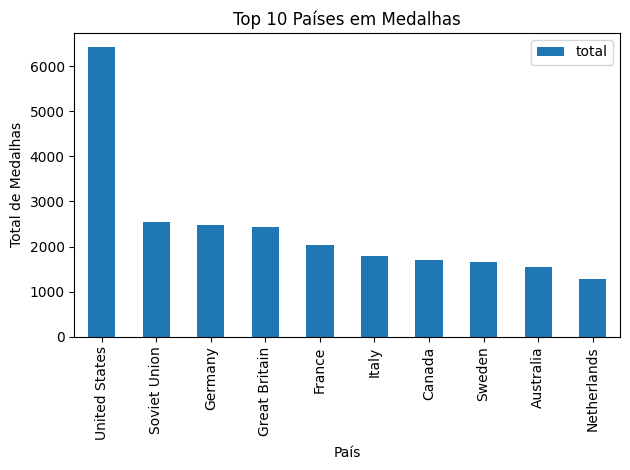

In [246]:
top10 = medalhas.sort_values(by='total', ascending=False).head(10)

top10.to_csv("gold/analise_medalhas/medalhas_top10.csv", index=False)

top10.plot(kind='bar', x='country', y='total')
plt.title("Top 10 Países em Medalhas")
plt.xlabel("País")
plt.ylabel("Total de Medalhas")
plt.tight_layout()
plt.savefig("gold/analise_medalhas/medalhas_plot.png")
plt.show()